# Is it a T2 echo?

[`01_build.ipynb`](01_build.ipynb) checked the sequence against arithmetic: `sc.kspace` puts k at
$10^{-7}$ 1/m on all three axes at every echo sample. **Everything it asserted would still hold for
a sequence whose 180 did not refocus at all** — the gradient areas would balance just as exactly
around a pulse that did nothing.

So this notebook measures the claims that need a magnetisation rather than a waveform:

| | |
|---|---|
| **1. T2 against T2\*** | sweep TE and fit a mono-exponential per tissue. The spin echo has to recover the phantom's **T2**; the same sweep without the 180 gives **T2\***, shorter by what the T2′ map sets. This is the headline |
| **2. B0 insensitivity** | a spread of off-resonance inside one voxel. The gradient echo loses it; the spin echo does not |
| **3. the CPMG phase at one echo** | with `B1 = 0.8` the 180 is imperfect. At **one** echo the difference between 0° and 90° is *phase only* — which is why the interesting version of this measurement is in [`../fse_2d/02`](../fse_2d/02_simulate_and_reconstruct.ipynb) |
| **4. the image** | the 128-line `.seq` against the BrainWeb slab, and which weighting the protocol actually landed on |

The **crusher balance on `z`** is *not* among them, and the last row of the summary says why.

**Needs `seqcraft[sim,recon]`** — MRzeroCore, torch and sigpy — and the same ~19 MB BrainWeb phantom
`gre_2d/02` downloads into `examples/data/`.

In [1]:
import os

# Set before torch is imported, which is where it reads them.  MRzero's inner loop is dense
# complex linear algebra and it will take every core it is offered; this notebook does not need it.
SIM_THREADS = 4
for _var in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'RAYON_NUM_THREADS',
             'OPENBLAS_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[_var] = str(SIM_THREADS)

import tempfile
import urllib.request
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import MRzeroCore as mr0
import numpy as np
import pypulseq as pp
import torch

import seqcraft as sc

torch.set_num_threads(SIM_THREADS)
plt.rcParams['figure.dpi'] = 56          # keeps the committed notebook a readable size

SEQ_DIR = Path('seq')
nominal = np.load(SEQ_DIR / 'se_2d_nominal.npz')

MATRIX = tuple(int(v) for v in nominal['matrix'])
FOV_MM = tuple(float(v) for v in nominal['fov_mm'])
THICKNESS_MM = float(nominal['thickness_mm'])
CENTER_LINE = int(nominal['center_line'])
TE_S, TR_S = float(nominal['te_s']), float(nominal['tr_s'])
NX, NY = MATRIX
NOISE_SNR = 60           # per coil, per k-space sample

opts = pp.Opts(
    max_grad=32, grad_unit='mT/m',
    max_slew=130, slew_unit='T/m/s',
    B0=3.0,
    rf_dead_time=100e-6,
    rf_ringdown_time=30e-6,
    adc_dead_time=10e-6,
)
grad_raster = sc.Raster(opts.grad_raster_time)

# The two shipped modules the probe below needs, on `01`'s protocol.  `SE2D` itself stays in `01`:
# what this notebook measures is a magnetisation, and for that the encoding is in the way.
exc = sc.modules.Excitation(opts=opts, flip_deg=90.0, thickness_mm=THICKNESS_MM,
                            duration_s=float(nominal['excite_duration_s']))
refoc = sc.modules.Refocusing(opts=opts,
                              thickness_mm=THICKNESS_MM * float(nominal['refocus_factor']),
                              duration_s=float(nominal['refocus_duration_s']),
                              crush_cycles_per_voxel=float(nominal['crush_cycles_slice']),
                              crush_voxel_mm=THICKNESS_MM)

print(f'{NX} x {NY}, TE {TE_S * 1e3:.2f} ms, TR {TR_S:.1f} s')
print(f'excitation centre {exc.time_to_center() * 1e3:.3f} ms, refocusing centre '
      f'{refoc.time_to_center() * 1e3:.3f} ms into its own block')
print(f'{torch.get_num_threads()} simulation threads of {os.cpu_count()} cores; the whole '
      f'notebook is about 30 s of work.')

D:\MIniconda\envs\NUM\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


D:\MIniconda\envs\NUM\Lib\site-packages\sigpy\config.py:27: UserWarning: Importing cupy.cuda.cudnn failed. For more details, see the error stack below:
DLL load failed while importing cudnn: The specified module could not be found.
  warnings.warn(


128 x 128, TE 10.70 ms, TR 2.0 s
excitation centre 1.350 ms, refocusing centre 2.800 ms into its own block
4 simulation threads of 32 cores; the whole notebook is about 30 s of work.


---
## 1. The probe, and why it carries no encoding

The question in §1–§3 is *how much signal is there at the echo*, so the probe is a 90, a 180 placed
so its **effective centre** lands at TE/2, and an ADC at TE. No phase encoding, no readout gradient,
no image: an encoded readout would answer the same question through a Fourier transform and a
gridding convention, both of which can be wrong in ways that look like physics.

Two things are deliberately kept:

- **the real `Refocusing` block, crushers and all.** They are what dephase the FID an imperfect 180
  leaves behind, and §3 needs that to be true rather than assumed.
- **`time_to_center()` on both pulses.** TE is centre to centre. Referencing it to the block edges
  would be a 1.3 ms error in a 20 ms measurement, and every fitted T2 below would come out wrong by
  a factor no other number could contradict.

`mr0.Sequence.import_file` on a written `.seq` throughout — the file a scanner would play, not the
tree that produced it. It is what would catch `use='refocusing'` failing to survive the round trip.

In [2]:
def probe(te_s, *, refocus=True, refoc_phase_deg=0.0):
    """A 90, optionally a 180 at TE/2, and eight samples straddling TE."""
    tree = sc.LogicBlock('probe').add(0.0, exc(phase_deg=90.0))
    if refocus:
        tree.add(float(grad_raster.ceil(exc.time_to_center() + te_s / 2 - refoc.time_to_center())),
                 refoc(phase_deg=refoc_phase_deg))
    return tree.add(float(grad_raster.ceil(exc.time_to_center() + te_s - 4e-5)),
                    pp.make_adc(num_samples=8, dwell=1e-5, delay=1e-5, system=opts))


def voxels(*, t1_s, t2_s, t2dash_s, b0_spread_hz=0.0, b1=1.0, count=15):
    """
    `count` co-located spins of one tissue, spread linearly over +/- `b0_spread_hz`.

    Co-located rather than adjacent, because the question is what happens *inside* one voxel: a
    single spin at a constant off-resonance only acquires a phase, and a magnitude image cannot
    see a phase.  A **spread** is what a gradient echo loses and a spin echo does not.

    Python floats rather than numpy scalars: a numpy value makes ``voxel_pos`` float64, which
    promotes the magnetisation to complex128 and then fails against the simulator's own complex64
    coil array -- a dtype error a long way from its cause.
    """
    built = mr0.CustomVoxelPhantom(
        pos=[[0.0, 0.0, 0.0]] * count, PD=[1.0 / count] * count, T1=[float(t1_s)] * count,
        T2=[float(t2_s)] * count, T2dash=[float(t2dash_s)] * count, D=[0.0] * count,
        voxel_size=THICKNESS_MM / 1e3, voxel_shape='box',
    ).build()
    spread = np.linspace(-b0_spread_hz, b0_spread_hz, count) if count > 1 else [b0_spread_hz]
    built.B0 = torch.tensor(spread, dtype=torch.float32)
    built.B1 = built.B1.float() * 0 + float(b1)
    return built


def simulate(tree, phantom, *, scratch=None):
    """Compile to a `.seq`, import it back, and simulate -- so the check is on the file."""
    with tempfile.TemporaryDirectory(prefix='se-probe-') as made:
        path = Path(scratch or made) / 'probe.seq'
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', sc.SeqCraftWarning)
            sc.compile(tree, opts, name='probe').write(str(path))
        seq = mr0.Sequence.import_file(str(path))
        graph = mr0.compute_graph(seq, phantom, max_state_count=200, min_state_mag=1e-4)
        return np.asarray(mr0.execute_graph(graph, seq, phantom, print_progress=False))[:, 0]


def at_echo(signal):
    """The complex sample of largest magnitude -- the echo, whatever raster it landed on."""
    return signal[np.abs(signal).argmax()]


#: The two brain tissues in the slice, with the T2' that makes T2* differ from T2.
TISSUES = {
    'white matter': dict(t1_s=0.86, t2_s=0.08, t2dash_s=0.030),
    'grey matter': dict(t1_s=1.58, t2_s=0.10, t2dash_s=0.040),
}
TE_SWEEP = (0.020, 0.040, 0.080, 0.160)

print(f'probe at TE = 80 ms: {probe(0.08).describe().splitlines()[0]}')
print(f'crusher winds {float(nominal["crush_cycles_slice"]):.0f} turns across the '
      f'{THICKNESS_MM:.0f} mm probe voxel')

probe at TE = 80 ms: probe  81.41 ms
crusher winds 3 turns across the 5 mm probe voxel


---
## 2. T2 against T2\*

The same sweep twice: with the refocusing pulse and without it. Nothing else differs — the same 90,
the same TE, the same ADC — so whatever separates the two fitted numbers is the pulse.

$$S(\mathrm{TE}) = S_0 e^{-\mathrm{TE}/T_2} \quad\text{against}\quad
S_0 e^{-\mathrm{TE}/T_2^{*}}, \qquad \frac{1}{T_2^{*}} = \frac{1}{T_2} + \frac{1}{T_2'}$$

The ground truth is in the phantom, so this is a table of numbers rather than a picture.

In [3]:
measured = {}
for name, tissue in TISSUES.items():
    phantom = voxels(**tissue)
    measured[name] = {
        'spin echo': np.array([abs(at_echo(simulate(probe(te), phantom))) for te in TE_SWEEP]),
        'gradient echo': np.array([abs(at_echo(simulate(probe(te, refocus=False), phantom)))
                                   for te in TE_SWEEP]),
    }


def fitted_s(signal, tes=TE_SWEEP):
    """The time constant of a mono-exponential, by a straight-line fit to log S."""
    return -1.0 / np.polyfit(tes, np.log(signal), 1)[0]


print(f'{"tissue":14s} {"T2 truth":>9s} {"T2 fitted":>10s} {"T2* truth":>10s} {"T2* fitted":>11s}')
for name, tissue in TISSUES.items():
    t2, t2dash = tissue['t2_s'], tissue['t2dash_s']
    t2star = 1 / (1 / t2 + 1 / t2dash)
    print(f'{name:14s} {t2 * 1e3:8.1f}ms {fitted_s(measured[name]["spin echo"]) * 1e3:9.1f}ms '
          f'{t2star * 1e3:9.1f}ms {fitted_s(measured[name]["gradient echo"]) * 1e3:10.1f}ms')
print()
print('The spin echo recovers T2 and the gradient echo recovers T2*, from the same excitation and')
print('the same echo time -- the one claim no amount of arithmetic in 01 could make.')

tissue          T2 truth  T2 fitted  T2* truth  T2* fitted
white matter       80.0ms      80.0ms      21.8ms       21.8ms
grey matter       100.0ms     100.0ms      28.6ms       28.6ms

The spin echo recovers T2 and the gradient echo recovers T2*, from the same excitation and
the same echo time -- the one claim no amount of arithmetic in 01 could make.


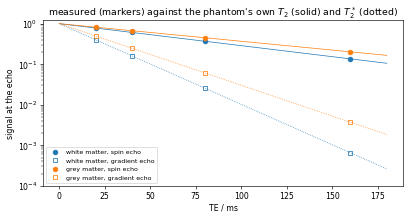

In [4]:
fig, ax = plt.subplots(figsize=(7.4, 4.0))
fine = np.linspace(0, 0.18, 200)
for index, (name, tissue) in enumerate(TISSUES.items()):
    t2star = 1 / (1 / tissue['t2_s'] + 1 / tissue['t2dash_s'])
    ax.semilogy(np.array(TE_SWEEP) * 1e3, measured[name]['spin echo'], 'o', color=f'C{index}',
                label=f'{name}, spin echo')
    ax.semilogy(np.array(TE_SWEEP) * 1e3, measured[name]['gradient echo'], 's', mfc='none',
                color=f'C{index}', label=f'{name}, gradient echo')
    ax.semilogy(fine * 1e3, measured[name]['spin echo'][0]
                * np.exp(-(fine - TE_SWEEP[0]) / tissue['t2_s']), '-', lw=0.9, color=f'C{index}')
    ax.semilogy(fine * 1e3, measured[name]['gradient echo'][0]
                * np.exp(-(fine - TE_SWEEP[0]) / t2star), ':', lw=0.9, color=f'C{index}')
ax.set(xlabel='TE / ms', ylabel='signal at the echo', ylim=(1e-4, 1.2),
       title='measured (markers) against the phantom\'s own $T_2$ (solid) and $T_2^*$ (dotted)')
ax.legend(fontsize=8)
fig.tight_layout()

---
## 3. B0 insensitivity, and the CPMG phase at one echo

**A constant off-resonance is only a phase**, and a magnitude image cannot see one. What a gradient
echo actually loses is the *spread* of off-resonance inside a voxel — which is what T2′ already
models, and which a refocusing pulse undoes exactly. So the experiment is a spread rather than an
offset, and it is measured at one TE with everything else held.

The CPMG measurement below is the one to read carefully. With `B1 = 0.8` the refocusing pulse turns
144° instead of 180°, and at **one** echo the difference between refocusing about `+x` and about
`+y` is entirely in the **phase**: both give the same magnitude. That is not a null result, it is
the reason the interesting version of this measurement needs a *train* — the phase error
accumulates, and after sixteen echoes it is the difference between a smooth decay and a collapse.
[`../fse_2d/02`](../fse_2d/02_simulate_and_reconstruct.ipynb) measures exactly that.

In [5]:
TE_PROBE = 0.080
tissue = TISSUES['white matter']

print(f'{"":26s} {"spin echo":>11s} {"gradient echo":>14s}')
for spread_hz in (0.0, 150.0):
    phantom = voxels(**tissue, b0_spread_hz=spread_hz)
    spin = abs(at_echo(simulate(probe(TE_PROBE), phantom)))
    gradient = abs(at_echo(simulate(probe(TE_PROBE, refocus=False), phantom)))
    print(f'B0 spread +/- {spread_hz:5.0f} Hz     {spin:11.4f} {gradient:14.4f}')
print(f'\nat TE = {TE_PROBE * 1e3:.0f} ms, and the spin echo does not move at all')
print()

imperfect = voxels(**tissue, b1=0.8)
print(f'{"B1 = 0.8, one echo":26s} {"|S|":>11s} {"arg S":>14s}')
for phase_deg, note in ((90.0, 'refocus about +y -- the same axis as the excitation'),
                        (0.0, 'refocus about +x -- the CPMG condition')):
    value = at_echo(simulate(probe(TE_PROBE, refoc_phase_deg=phase_deg), imperfect))
    print(f'refocusing phase {phase_deg:5.1f} deg  {abs(value):11.4f} '
          f'{np.angle(value, deg=True):13.1f}   {note}')
print()
print('Same magnitude, opposite phase.  One echo cannot tell them apart, and a train can.')

                             spin echo  gradient echo
B0 spread +/-     0 Hz          0.3678         0.0256
B0 spread +/-   150 Hz          0.3678         0.0017

at TE = 80 ms, and the spin echo does not move at all

B1 = 0.8, one echo                 |S|          arg S
refocusing phase  90.0 deg       0.3164         -90.0   refocus about +y -- the same axis as the excitation


refocusing phase   0.0 deg       0.3164          90.0   refocus about +x -- the CPMG condition

Same magnitude, opposite phase.  One echo cannot tell them apart, and a train can.


---
## 4. The image

Now the sequence itself: the 128-line `.seq` that `01` wrote, against the BrainWeb slab.

The workflow is `gre_2d/02`'s, deliberately, so the *sequence* is the only thing that differs — a
slab spanning the slice (a one-voxel-thick phantom reads a slice-select gradient as complete
dephasing and returns exactly zero signal), the same eight-element receive ring, complex Gaussian
noise at a stated SNR, ESPIRiT maps and a SENSE inverse.

**Sorted by the labels read back out of the file**, never from the build-time table. That is the
`mp2rage_2d/02` pattern and it is the independent check that the labels a reconstruction depends on
are the ones the sequence emitted.

In [6]:
PHANTOM_URL = ('https://github.com/MRsources/MRzero-Core/raw/main/'
               'documentation/playground_mr0/subject05.npz')
PHANTOM = Path('../data/subject05.npz')

if not PHANTOM.exists():
    PHANTOM.parent.mkdir(parents=True, exist_ok=True)
    print(f'downloading {PHANTOM_URL} -> {PHANTOM} (~19 MB, once)')
    urllib.request.urlretrieve(PHANTOM_URL, PHANTOM)

NZ, N_COILS = 4, 8


def coil_ring(nx, ny, nz, n_coils=N_COILS):
    """A ring of `n_coils` surface coils around the object, as complex sensitivities."""
    gx, gy = np.meshgrid(np.linspace(-1, 1, nx), np.linspace(-1, 1, ny), indexing='ij')
    sens = np.stack([
        np.exp(-((gx - 1.5 * np.cos(a)) ** 2 + (gy - 1.5 * np.sin(a)) ** 2) / 1.5)
        * np.exp(1j * np.arctan2(gy - np.sin(a), gx - np.cos(a)))
        for a in np.arange(n_coils) * 2 * np.pi / n_coils
    ]).astype(np.complex64)
    return torch.tensor(np.repeat(sens[:, :, :, None], nz, axis=3))


whole = mr0.VoxelGridPhantom.load(PHANTOM).interpolate(NX, NX, 128)
phantom = whole.slices(list(range(64 - NZ // 2, 64 + NZ - NZ // 2)))
# slices() leaves the slab where it was in the volume.  Put it at isocentre, which is where the
# sequence excites -- otherwise the slice profile selects the wrong tissue, or none at all, and
# the symptom is a dark image rather than an error.
phantom.affine[2, 3] = -0.5 * NZ * float(phantom.affine[2, 2])
phantom.coil_sens = coil_ring(NX, NX, NZ)
data = phantom.build()

mid = NZ // 2
t1_map = phantom.T1[:, :, mid].numpy().T
t2_map = phantom.T2[:, :, mid].numpy().T
brain = t1_map > 0.2

print(f'{tuple(phantom.PD.shape)} voxels, {N_COILS} coils')
print(f'T2 in the slice: {t2_map[brain].min() * 1e3:.0f} .. {t2_map[brain].max() * 1e3:.0f} ms, '
      f'and the sequence samples it at TE = {TE_S * 1e3:.1f} ms')

(128, 128, 4) voxels, 8 coils
T2 in the slice: 76 .. 1650 ms, and the sequence samples it at TE = 10.7 ms


In [7]:
def lin_labels(path):
    """The LIN label of every acquired readout, read back out of the written file."""
    seq = pp.Sequence(system=opts)
    seq.read(str(path))
    return [int(v) for v in np.atleast_1d(np.asarray(
        seq.evaluate_labels(evolution='adc')['LIN']))]


def to_grid(signal, lines):
    """Scatter one readout per entry of `lines` into a (coils, ny, nx) array."""
    samples = np.asarray(signal).reshape(len(lines), NX, -1)     # (readout, sample, coil)
    grid = np.zeros((samples.shape[2], NY, NX), dtype=np.complex64)
    grid[:, list(lines), :] = samples.transpose(2, 0, 1)
    return grid


def ifft2c(ksp):
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(ksp, axes=(-2, -1)), norm='ortho'),
                           axes=(-2, -1))


def rss(image):
    return np.sqrt((np.abs(image) ** 2).sum(0))


def add_noise(ksp, lines, sigma, seed=0):
    """Complex Gaussian noise on the *sampled* rows only, circularly symmetric."""
    rng = np.random.default_rng(seed)
    noise = np.zeros_like(ksp)
    shape = (ksp.shape[0], len(lines), ksp.shape[2])
    noise[:, list(lines), :] = (sigma / np.sqrt(2)) * (
        rng.standard_normal(shape) + 1j * rng.standard_normal(shape))
    return ksp + noise.astype(np.complex64)


def acquire(name):
    """Import the written .seq, simulate it, and grid it by the labels it carries."""
    path = SEQ_DIR / f'{name}.seq'
    lines = lin_labels(path)
    seq = mr0.Sequence.import_file(str(path))
    graph = mr0.compute_graph(seq, data, max_state_count=200, min_state_mag=1e-4)
    signal = mr0.execute_graph(graph, seq, data, min_emitted_signal=1e-4,
                               min_latent_signal=1e-5, print_progress=False)
    return lines, to_grid(signal, lines)


lines, clean = acquire('se_2d')
assert sorted(lines) == list(range(NY)), 'the file does not cover k-space exactly once'

k_parsed = mr0.Sequence.import_file(str(SEQ_DIR / 'se_2d.seq')).get_kspace()[:, :3].numpy().T
worst = np.abs(k_parsed.reshape(3, NY, NX)[:2] - nominal['k'][:2]).max() / (1e3 / FOV_MM[0])
print(f'{len(lines)} LIN labels, a permutation of range({NY})')
print(f'parsed vs nominal k, worst axis-wise difference: {worst:.2e} dk')
assert worst < 1e-3

128 LIN labels, a permutation of range(128)
parsed vs nominal k, worst axis-wise difference: 1.29e-04 dk


In [8]:
import sigpy.mri as smri

SIGMA = float(rss(ifft2c(clean)).max()) / NOISE_SNR
ksp = add_noise(clean, lines, SIGMA)
maps = smri.app.EspiritCalib(ksp, show_pbar=False).run()
image = np.abs(smri.app.SenseRecon(ksp, maps, lamda=1e-3, show_pbar=False).run())

zero_filled = rss(ifft2c(ksp))
corner = np.r_[zero_filled[:12, :12].ravel(), zero_filled[-12:, -12:].ravel()]
inside = zero_filled > 0.25 * zero_filled.max()
print(f'noise sigma {SIGMA:.4g} per coil per sample, for an image SNR of {NOISE_SNR}')
print(f'measured signal / background {zero_filled[inside].mean() / corner.std():.1f}')

noise sigma 9.075 per coil per sample, for an image SNR of 60
measured signal / background 90.3


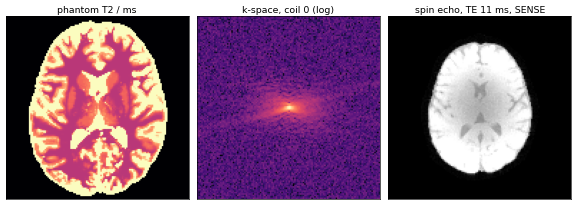

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(10.4, 3.7))
axes[0].imshow(t2_map * 1e3, origin='lower', cmap='magma', vmin=0, vmax=150)
axes[0].set(title='phantom T2 / ms', xticks=[], yticks=[])
axes[1].imshow(np.log1p(np.abs(ksp[0])), origin='lower', cmap='magma')
axes[1].set(title='k-space, coil 0 (log)', xticks=[], yticks=[])
axes[2].imshow(image, origin='lower', cmap='gray', vmin=0, vmax=0.8 * image.max())
axes[2].set(title=f'spin echo, TE {TE_S * 1e3:.0f} ms, SENSE', xticks=[], yticks=[])
fig.tight_layout()

### Which weighting did this protocol actually land on?

The full spin-echo signal equation, not just the T2 term:

$$S = \mathrm{PD}\,\big(1 - e^{-\mathrm{TR}/T_1}\big)\,e^{-\mathrm{TE}/T_2}$$

and at **TE = 10.7 ms** — the shortest this sequence can do — the middle factor is the one that
moves. Grey matter's 1.58 s T1 is not recovered in a 2 s TR while white matter's 0.86 s nearly is,
so the residual saturation more than cancels grey matter's longer T2. **This is a
proton-density-weighted spin echo, not a T2-weighted one.**

Getting a T2-weighted image means a TE of 80–100 ms, and paying for it one line per TR is four
minutes for one contrast. That is the whole argument for
[`../fse_2d/`](../fse_2d/01_build.ipynb): the same TE at sixteen echoes per shot is sixteen seconds.

Measured in a **central box**, because the receive ring's sensitivity varies by more across the
image than the tissues do, so a whole-brain comparison would be a picture of the coil array.

In [10]:
box = np.zeros_like(brain)
box[NY // 2 - 24:NY // 2 + 24, NX // 2 - 24:NX // 2 + 24] = True
pd_map = phantom.PD[:, :, mid].numpy().T
# Classified by T1, as ../mprage_2d/02 does, so the two notebooks are measuring the same tissue
# under two weightings rather than two definitions of "white matter".
classes = {'white': (t1_map < 1.1) & brain & box, 'grey': (t1_map > 1.3) & brain & box}

print(f'{"class":8s} {"voxels":>7s} {"median T1":>11s} {"median T2":>11s} {"predicted":>11s} '
      f'{"measured":>10s}')
predicted, got = {}, {}
for label, mask in classes.items():
    t1, t2 = float(np.median(t1_map[mask])), float(np.median(t2_map[mask]))
    predicted[label] = (float(np.median(pd_map[mask])) * (1 - np.exp(-TR_S / t1))
                        * np.exp(-TE_S / t2))
    got[label] = float(image[mask].mean())
    print(f'{label:8s} {int(mask.sum()):7d} {t1:10.2f}s {t2 * 1e3:10.1f}ms '
          f'{predicted[label]:11.3f} {got[label]:10.3f}')

print()
print(f'predicted grey/white ratio {predicted["grey"] / predicted["white"]:.3f}')
print(f'measured                   {got["grey"] / got["white"]:.3f}')
print()
print('Grey matter is the *darker* of the two at this TE, and the T2 term is not why: at 10.7 ms')
print('it favours grey by 5 %, and the T1 saturation at TR = 2 s favours white by 21 %.')

class     voxels   median T1   median T2   predicted   measured
white        994       0.86s       76.7ms       0.552    372.052
grey        1113       1.58s      115.3ms       0.524    344.477

predicted grey/white ratio 0.950
measured                   0.926

Grey matter is the *darker* of the two at this TE, and the T2 term is not why: at 10.7 ms
it favours grey by 5 %, and the T1 saturation at TR = 2 s favours white by 21 %.


---
## What this notebook established

| | |
|---|---|
| the spin echo recovers the phantom's **T2**, the same sweep without the 180 recovers **T2\*** | 80.0 / 100.0 ms against 21.8 / 28.6 ms, fitted, from the same excitation and the same echo time. **The one claim arithmetic could not make** |
| a spread of off-resonance inside a voxel costs the gradient echo everything and the spin echo nothing | which is the same statement as the first one, read at one TE instead of four |
| at **one** echo the CPMG condition is a **phase** difference, not an amplitude one | so the measurement that matters is over a train, and it is in [`../fse_2d/02`](../fse_2d/02_simulate_and_reconstruct.ipynb) |
| at TE = 10.7 ms this is a **proton-density** weighted spin echo | the T1 saturation at TR = 2 s outweighs the T2 difference, and the T2-weighted version needs TE ~ 80 ms and therefore an echo train |
| **the crusher balance on `z` is not measured here** | a slab four voxels thick has nothing for a slice gradient to dephase across within a voxel, so an unbalanced crusher simulates as perfectly fine. `01` asserts it arithmetically and `tests/modules/test_refocusing.py` asserts the alternating failure mode |

Next: [`../fse_2d/01_build.ipynb`](../fse_2d/01_build.ipynb) turns the one echo into sixteen — and
[`../fse_2d/02`](../fse_2d/02_simulate_and_reconstruct.ipynb) measures what the train costs, which
is where the CPMG condition finally has something to do.